# Song Verse Key Analysis

This notebook analyzes the keys/verses in the song database and provides statistics on:
- Most common verse types (chorus, verse, bridge, etc.)
- Distribution of verses per song
- Songs with region 2 markers
- Key patterns and naming conventions

## 1. Import Required Libraries

In [17]:
import pandas as pd
import sqlite3
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import sys
sys.path.append('local_function')
from convert_contents import extract_key_in_verse, split_content_into_verse, remove_fault_brackets

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

## 2. Load Data from Database

In [18]:
# Connect to the database
conn = sqlite3.connect('download_db/Dedupe_Pooled_Database_2023_curated.db')

# Load the data
sql_query = pd.read_sql_query('''
    SELECT
    title1,
    title2,
    contents,
    sequence
    FROM items
    ''', conn)

df = pd.DataFrame(sql_query, columns=['title1', 'title2', 'contents', 'sequence'])
print(f"Total songs in database: {len(df)}")
df.head()

Total songs in database: 258


,title1,title2,contents,sequence
0,As We Come Into Your Presence (Awesome in This...,,As we come into Your presence\nPast the gates ...,
1,At the Cross (W),,"[1]\nOh, Lord You've searched me \n\nYou know ...","1,2,3,c,b"
2,Awesome God (P),,[chorus]\nOur God is an awesome God\n\nHe reig...,"c,e"
3,Be magnified (W),Dâng Chúa Tâm Hồn,[1]\nI have made You too small in my eyes\n\nO...,"1,c,2,c"
4,Be with You (W),Saviour of My Soul,[1]\nSavior of my soul\n\nI confide in You\n\n...,"c,d,e,1,2"


## 3. Extract Keys from All Songs

In [19]:
# Extract all keys from the contents
# First apply remove_fault_brackets to convert [x4] and similar to (x4)
df['keys'] = df['contents'].apply(lambda x: extract_key_in_verse(remove_fault_brackets(x)) if pd.notna(x) else [])
df['num_verses'] = df['keys'].apply(len)
df['has_region2'] = df['contents'].apply(lambda x: '[region 2]' in str(x) if pd.notna(x) else False)

print(f"Songs with verses: {df['num_verses'].gt(0).sum()}")
print(f"Songs with region 2 markers: {df['has_region2'].sum()}")
df[['title1', 'keys', 'num_verses', 'has_region2']].head(10)

Songs with verses: 256
Songs with region 2 markers: 202


,title1,keys,num_verses,has_region2
0,As We Come Into Your Presence (Awesome in This...,[chorus],1,False
1,At the Cross (W),"[1, chorus, 2, bridge, 3, 4]",6,True
2,Awesome God (P),"[chorus, ending]",2,True
3,Be magnified (W),"[1, chorus, 2]",3,True
4,Be with You (W),"[1, 2, chorus, chorus 2, ending]",5,True
5,Because of You (City Harvest) (W),"[1, 2, chorus, 3, bridge]",5,True
6,Blessed be the Name of the Lord (Clinton Huber...,"[chorus, 1, 2, 3]",4,True
7,Blessed Be Your Name! (P),"[1, prechorus, chorus, 2, bridge, 3]",6,True
8,Break every chains (P),"[1, chorus, bridge, 2, ending]",5,True
9,Broken vessle (W),"[1, prechorus, chorus, 2]",4,True


## 4. Key Statistics Overview

In [20]:
# Flatten all keys into a single list
all_keys = [key for keys_list in df['keys'] for key in keys_list]
print(f"Total number of verse markers: {len(all_keys)}")
print(f"Unique verse types: {len(set(all_keys))}")
print(f"\nBasic statistics:")
print(df['num_verses'].describe())

Total number of verse markers: 1007
Unique verse types: 14

Basic statistics:
count    258.000000
mean       3.903101
std        1.773758
min        0.000000
25%        3.000000
50%        4.000000
75%        5.000000
max        8.000000
Name: num_verses, dtype: float64


## 5. Most Common Verse Types

In [21]:
# Count frequency of each key type
key_counts = Counter(all_keys)
top_keys = key_counts.most_common(20)

# Create a DataFrame for better display
top_keys_df = pd.DataFrame(top_keys, columns=['Key', 'Frequency'])
top_keys_df['Percentage'] = (top_keys_df['Frequency'] / len(all_keys) * 100).round(2)
print("\nTop 20 Most Common Verse Types:")
print(top_keys_df.to_string(index=False))


Top 20 Most Common Verse Types:
        Key  Frequency  Percentage
          1        246       24.43
     chorus        226       22.44
          2        137       13.60
     ending        116       11.52
     bridge        111       11.02
  prechorus         55        5.46
          3         41        4.07
   chorus 2         28        2.78
        tag         19        1.89
          4         11        1.09
   bridge 2         10        0.99
prechorus 2          4        0.40
   bridge 3          2        0.20
      intro          1        0.10


### 5.1. Songs with "Intro" Key

In [22]:
# Find songs that contain "intro" key (case-insensitive)
intro_songs = df[df['keys'].apply(lambda keys: any('intro' in key.lower() for key in keys))]

print(f"Total songs with 'intro' key: {len(intro_songs)}")
print(f"Percentage: {len(intro_songs) / len(df) * 100:.2f}%\n")

# Show the intro keys found
intro_keys_found = [key for song_keys in intro_songs['keys'] for key in song_keys if 'intro' in key.lower()]
intro_key_counts = Counter(intro_keys_found)
print(f"Variations of 'intro' keys found:")
for key, count in intro_key_counts.most_common():
    print(f"  [{key}]: {count} times")

print(f"\nList of songs with 'intro' key:")
print(intro_songs[['title1', 'keys', 'num_verses']].to_string(index=False))

Total songs with 'intro' key: 1
Percentage: 0.39%

Variations of 'intro' keys found:
  [intro]: 1 times

List of songs with 'intro' key:
    title1                                         keys  num_verses
MẸ YÊU CON [intro, 1, chorus, 2, chorus 2, tag, ending]           7


## 6. Visualize Top Verse Types

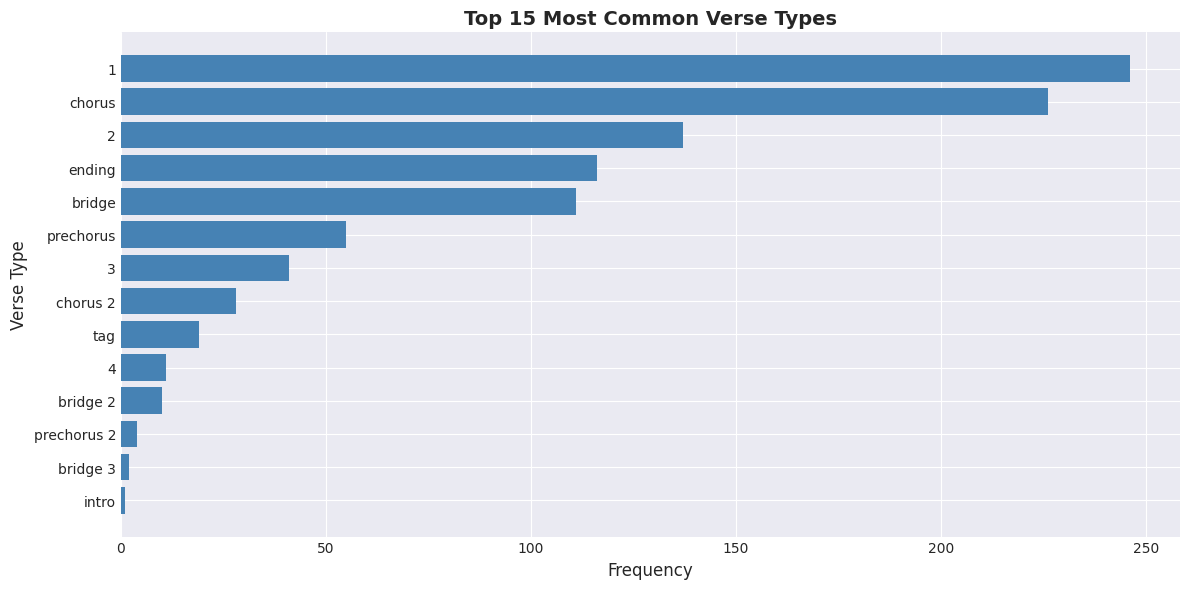

In [23]:
# Plot top 15 verse types
plt.figure(figsize=(12, 6))
top_15 = top_keys_df.head(15)
plt.barh(top_15['Key'], top_15['Frequency'], color='steelblue')
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('Verse Type', fontsize=12)
plt.title('Top 15 Most Common Verse Types', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 7. Distribution of Verses per Song

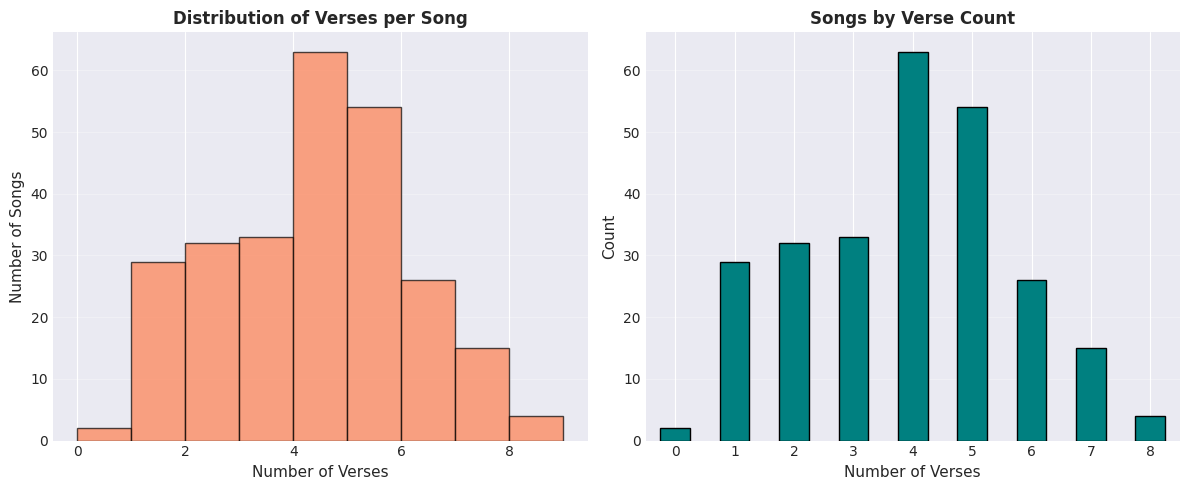


Songs with no verse markers: 2
Average verses per song: 3.90
Median verses per song: 4


In [24]:
# Plot distribution of verses per song
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df['num_verses'], bins=range(0, df['num_verses'].max() + 2), 
         color='coral', edgecolor='black', alpha=0.7)
plt.xlabel('Number of Verses', fontsize=11)
plt.ylabel('Number of Songs', fontsize=11)
plt.title('Distribution of Verses per Song', fontsize=12, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

plt.subplot(1, 2, 2)
df['num_verses'].value_counts().sort_index().plot(kind='bar', color='teal', edgecolor='black')
plt.xlabel('Number of Verses', fontsize=11)
plt.ylabel('Count', fontsize=11)
plt.title('Songs by Verse Count', fontsize=12, fontweight='bold')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nSongs with no verse markers: {(df['num_verses'] == 0).sum()}")
print(f"Average verses per song: {df['num_verses'].mean():.2f}")
print(f"Median verses per song: {df['num_verses'].median():.0f}")

## 8. Categorize Verse Types

In [25]:
# Categorize keys into groups
def categorize_key(key):
    key_lower = key.lower()
    if key.isdigit() or 'verse' in key_lower or key_lower.startswith('v'):
        return 'Verse'
    elif 'chorus' in key_lower or key_lower.startswith('c'):
        return 'Chorus'
    elif 'bridge' in key_lower or key_lower.startswith('b'):
        return 'Bridge'
    elif 'intro' in key_lower:
        return 'Intro'
    elif 'outro' in key_lower or 'ending' in key_lower:
        return 'Outro'
    elif 'tag' in key_lower:
        return 'Tag'
    elif 'pre' in key_lower:
        return 'Pre-Chorus'
    elif 'interlude' in key_lower:
        return 'Interlude'
    else:
        return 'Other'

# Apply categorization
key_categories = [categorize_key(key) for key in all_keys]
category_counts = Counter(key_categories)

# Display results
category_df = pd.DataFrame(category_counts.items(), columns=['Category', 'Count'])
category_df = category_df.sort_values('Count', ascending=False)
category_df['Percentage'] = (category_df['Count'] / len(all_keys) * 100).round(2)
print("\nVerse Type Categories:")
print(category_df.to_string(index=False))


Verse Type Categories:
Category  Count  Percentage
   Verse    435       43.20
  Chorus    313       31.08
  Bridge    123       12.21
   Outro    116       11.52
     Tag     19        1.89
   Intro      1        0.10


## 9. Visualize Verse Categories

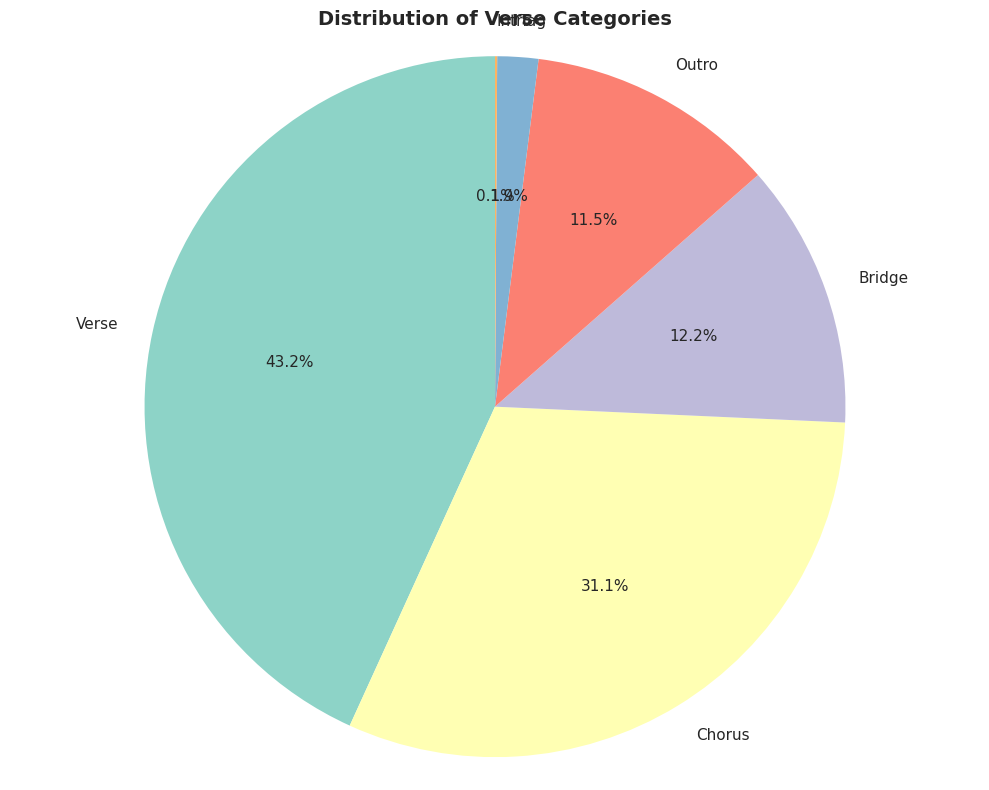

In [26]:
# Pie chart of verse categories
plt.figure(figsize=(10, 8))
colors = plt.cm.Set3(range(len(category_df)))
plt.pie(category_df['Count'], labels=category_df['Category'], autopct='%1.1f%%',
        startangle=90, colors=colors, textprops={'fontsize': 11})
plt.title('Distribution of Verse Categories', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

## 10. Songs with Region 2 Analysis

In [27]:
# Analyze songs with region 2
region2_songs = df[df['has_region2']]
print(f"Total songs with [region 2] marker: {len(region2_songs)}")
print(f"Percentage of songs with [region 2]: {len(region2_songs) / len(df) * 100:.2f}%")

print("\nSample songs with [region 2]:")
print(region2_songs[['title1', 'num_verses']].head(10).to_string(index=False))

Total songs with [region 2] marker: 202
Percentage of songs with [region 2]: 78.29%

Sample songs with [region 2]:
                                                        title1  num_verses
                                              At the Cross (W)           6
                                               Awesome God (P)           2
                                              Be magnified (W)           3
                                               Be with You (W)           5
                             Because of You (City Harvest) (W)           5
Blessed be the Name of the Lord (Clinton Hubert Utterbach) (P)           4
                                     Blessed Be Your Name! (P)           6
                                        Break every chains (P)           5
                                             Broken vessle (W)           4
                                          Christ Is enough (W)           6


## 11. Unique Key Patterns

In [28]:
# Find unique and rare key patterns
rare_keys = [key for key, count in key_counts.items() if count == 1]
print(f"\nNumber of unique keys (appearing only once): {len(rare_keys)}")
print(f"\nSample of unique keys:")
print(rare_keys[:20])

# Find keys with special characters or unusual patterns
unusual_keys = [key for key in set(all_keys) if not key.replace(' ', '').isalnum()]
print(f"\nKeys with special characters: {len(unusual_keys)}")
print(unusual_keys[:15])


Number of unique keys (appearing only once): 1

Sample of unique keys:
['intro']

Keys with special characters: 0
[]


## 12. Export Summary Statistics

In [29]:
# Create a summary report
summary = {
    'Total Songs': len(df),
    'Songs with Verses': df['num_verses'].gt(0).sum(),
    'Total Verse Markers': len(all_keys),
    'Unique Verse Types': len(set(all_keys)),
    'Songs with Region 2': df['has_region2'].sum(),
    'Average Verses per Song': round(df['num_verses'].mean(), 2),
    'Median Verses per Song': df['num_verses'].median(),
    'Max Verses in a Song': df['num_verses'].max(),
    'Min Verses in a Song': df['num_verses'].min()
}

summary_df = pd.DataFrame(list(summary.items()), columns=['Metric', 'Value'])
print("\n=== SUMMARY REPORT ===")
print(summary_df.to_string(index=False))

# # Save to CSV
# summary_df.to_csv('verse_analysis_summary.csv', index=False)
# top_keys_df.to_csv('top_verse_types.csv', index=False)
# category_df.to_csv('verse_categories.csv', index=False)
# print("\n✓ Summary files saved: verse_analysis_summary.csv, top_verse_types.csv, verse_categories.csv")


=== SUMMARY REPORT ===
                 Metric  Value
            Total Songs  258.0
      Songs with Verses  256.0
    Total Verse Markers 1007.0
     Unique Verse Types   14.0
    Songs with Region 2  202.0
Average Verses per Song    3.9
 Median Verses per Song    4.0
   Max Verses in a Song    8.0
   Min Verses in a Song    0.0


## 13. Sample Song Analysis

In [30]:
# Detailed analysis of a few sample songs
sample_songs = df[df['num_verses'] > 0].sample(min(5, len(df)), random_state=42)

print("\n=== SAMPLE SONG VERSE STRUCTURES ===")
for idx, row in sample_songs.iterrows():
    print(f"\n{'='*60}")
    print(f"Song: {row['title1']}")
    print(f"Number of verses: {row['num_verses']}")
    print(f"Has region 2: {row['has_region2']}")
    print(f"Verse structure: {row['keys']}")
    print(f"\nFirst 200 characters of content:")
    print(row['contents'][:200] + "...")


=== SAMPLE SONG VERSE STRUCTURES ===

Song: MẸ LÀ HẠNH PHÚC CHÚA BAN (BG)
Number of verses: 1
Has region 2: False
Verse structure: ['1']

First 200 characters of content:
[1]
....

Song: Blessed be the Name of the Lord (Clinton Hubert Utterbach) (P)
Number of verses: 4
Has region 2: True
Verse structure: ['chorus', '1', '2', '3']

First 200 characters of content:
[chorus]
Blessed be the Name of the Lord

Blessed be the Name of the Lord

Blessed be the Name of the Lord

The most high
[region 2]
Đáng chúc tán ngợi khen Danh Chúa

Đáng chúc tán ngợi khen Danh Chú...

Song: My Redeemer lives (P)
Number of verses: 3
Has region 2: True
Verse structure: ['1', 'chorus', 'bridge']

First 200 characters of content:
[1]
I KNOW HE RESCUED MY SOUL

HIS BLOOD HAS COVERED MY SIN

I BELIEVE, I BELIEVE

MY SHAME HE’S TAKEN AWAY

MY PAIN IS HEALED IN HIS NAME

I BELIEVE, I BELIEVE

I’LL RAISE A BANNER 

CAUSE MY LORD HA...

Song: Slide Dang Hien GS
Number of verses: 1
Has region 2: True
Verse structure

## 14. Close Database Connection

In [31]:
# Close the database connection
conn.close()
print("Database connection closed.")

Database connection closed.
